# 🦍 Notebook 03 — Home Range Estimation
Estimates home ranges using two methods:
- **MCP** (Minimum Convex Polygon) — 95% and 50% (core area)
- **KDE** (Kernel Density Estimation) — 95% utilization distribution
- Seasonal home range variation
- Comparison across groups


## Cell 1 — Imports & Load Data

In [16]:
import sys, os, warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
from scipy.stats import gaussian_kde
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

project_root = os.path.abspath('..')
sys.path.insert(0, project_root)
from src.home_range import (
    mcp_home_range, kde_home_range,
    home_range_all_groups, seasonal_home_range
)

DATA_PATH = os.path.join(project_root, 'data', 'processed', 'gorilla_gps_clean.csv')
df = pd.read_csv(DATA_PATH, parse_dates=['timestamp','date'])
GROUPS = sorted(df['group_id'].unique())
COLORS = {'Susa':'#2E86AB','Hirwa':'#A23B72','Amahoro':'#F18F01',
          'Umubano':'#C73E1D','Pablo':'#3B1F2B','Kwitonda':'#44BBA4'}
print(f'Loaded {len(df):,} GPS fixes for {len(GROUPS)} groups')

Loaded 105,143 GPS fixes for 6 groups


## Cell 2 — MCP Home Range per Group

In [17]:
print('Computing MCP home ranges...')
mcp_results = {}
for group in GROUPS:
    sub = df[df['group_id']==group]
    lats = sub['latitude'].values
    lons = sub['longitude'].values
    r95 = mcp_home_range(lats, lons, percent=95)
    r50 = mcp_home_range(lats, lons, percent=50)
    mcp_results[group] = {
        'mcp_95': r95, 'mcp_50': r50,
        'n_fixes': len(lats)
    }
    print(f'  {group:10s}: 95% MCP = {r95["area_km2"]:.1f} km²  |  50% core = {r50["area_km2"]:.1f} km²')

Computing MCP home ranges...
  Amahoro   : 95% MCP = 8.2 km²  |  50% core = 2.5 km²
  Hirwa     : 95% MCP = 7.1 km²  |  50% core = 1.8 km²
  Kwitonda  : 95% MCP = 9.6 km²  |  50% core = 3.0 km²
  Pablo     : 95% MCP = 10.9 km²  |  50% core = 2.8 km²
  Susa      : 95% MCP = 13.3 km²  |  50% core = 3.7 km²
  Umubano   : 95% MCP = 8.4 km²  |  50% core = 2.5 km²


## Cell 3 — Visualize MCP Home Ranges

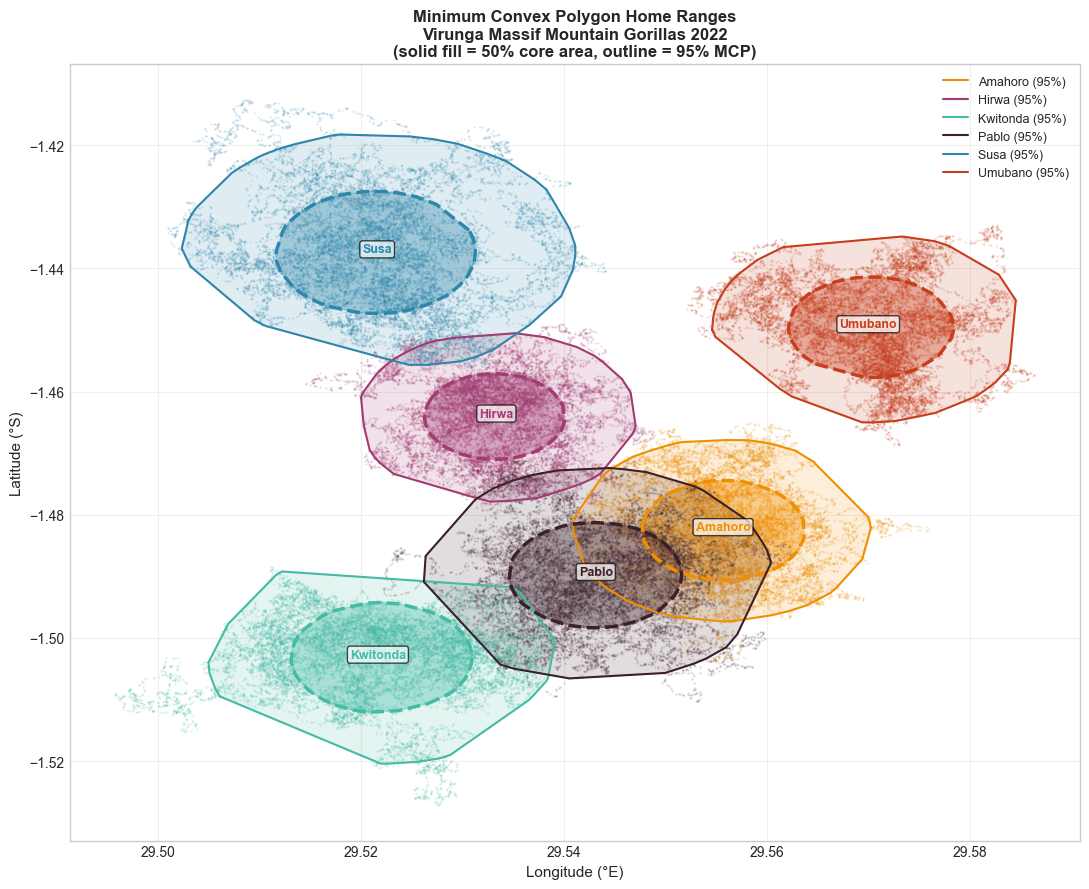

In [18]:
from shapely.geometry import Polygon

# ── helpers (defined ONCE, outside everything) ──────────────────────────────
def mcp_polygon(group, percent=95):
    res = mcp_results[group][f'mcp_{percent}']
    hull_lons = res.get('hull_lons')
    hull_lats = res.get('hull_lats')
    if hull_lons is None or hull_lats is None:
        return None
    return Polygon(zip(hull_lons, hull_lats))

# ── single figure ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))

for group in GROUPS:
    sub   = df[df['group_id'] == group]
    color = COLORS.get(group, 'gray')

    # GPS points
    ax.scatter(sub['longitude'], sub['latitude'],
               s=0.4, alpha=0.15, color=color)

    # 95% MCP polygon
    poly95 = mcp_polygon(group, 95)
    if poly95 is not None:
        xs95, ys95 = poly95.exterior.xy
        ax.fill(xs95, ys95, alpha=0.15, color=color)
        ax.plot(xs95, ys95, color=color, linewidth=1.5, label=f'{group} (95%)')

    # 50% core MCP polygon
    poly50 = mcp_polygon(group, 50)
    if poly50 is not None:
        xs50, ys50 = poly50.exterior.xy
        ax.fill(xs50, ys50, alpha=0.35, color=color)
        ax.plot(xs50, ys50, color=color, linewidth=2.5, linestyle='--')

    # Group label at centroid
    cx, cy = sub['longitude'].mean(), sub['latitude'].mean()
    ax.annotate(group, (cx, cy), fontsize=9, fontweight='bold',
                color=color, ha='center',
                bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.2'))

# ── labels / save / show (ONCE, after the loop) ──────────────────────────────
ax.set_xlabel('Longitude (°E)', fontsize=11)
ax.set_ylabel('Latitude (°S)', fontsize=11)
ax.set_title('Minimum Convex Polygon Home Ranges\nVirunga Massif Mountain Gorillas 2022\n'
             '(solid fill = 50% core area, outline = 95% MCP)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'outputs', 'figures', '03_mcp_home_ranges.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Cell 4 — KDE Home Range per Group

In [19]:
print('Computing KDE home ranges (this may take 1-2 minutes)...')
kde_results = {}
for group in GROUPS:
    sub = df[df['group_id']==group]
    lats = sub['latitude'].values
    lons = sub['longitude'].values
    res = kde_home_range(lats, lons, contour_levels=(95, 50), grid_n=150)
    kde_results[group] = res
    print(f'  {group:10s}: 95% KDE = {res["area_95pct_km2"]:.1f} km²  |  50% core = {res["area_50pct_km2"]:.1f} km²')

Computing KDE home ranges (this may take 1-2 minutes)...
  Amahoro   : 95% KDE = 8.3 km²  |  50% core = 2.4 km²
  Hirwa     : 95% KDE = 7.1 km²  |  50% core = 1.8 km²
  Kwitonda  : 95% KDE = 9.3 km²  |  50% core = 2.6 km²
  Pablo     : 95% KDE = 9.9 km²  |  50% core = 2.8 km²
  Susa      : 95% KDE = 13.7 km²  |  50% core = 3.5 km²
  Umubano   : 95% KDE = 8.1 km²  |  50% core = 2.3 km²


## Cell 5 — KDE Utilization Distribution Maps

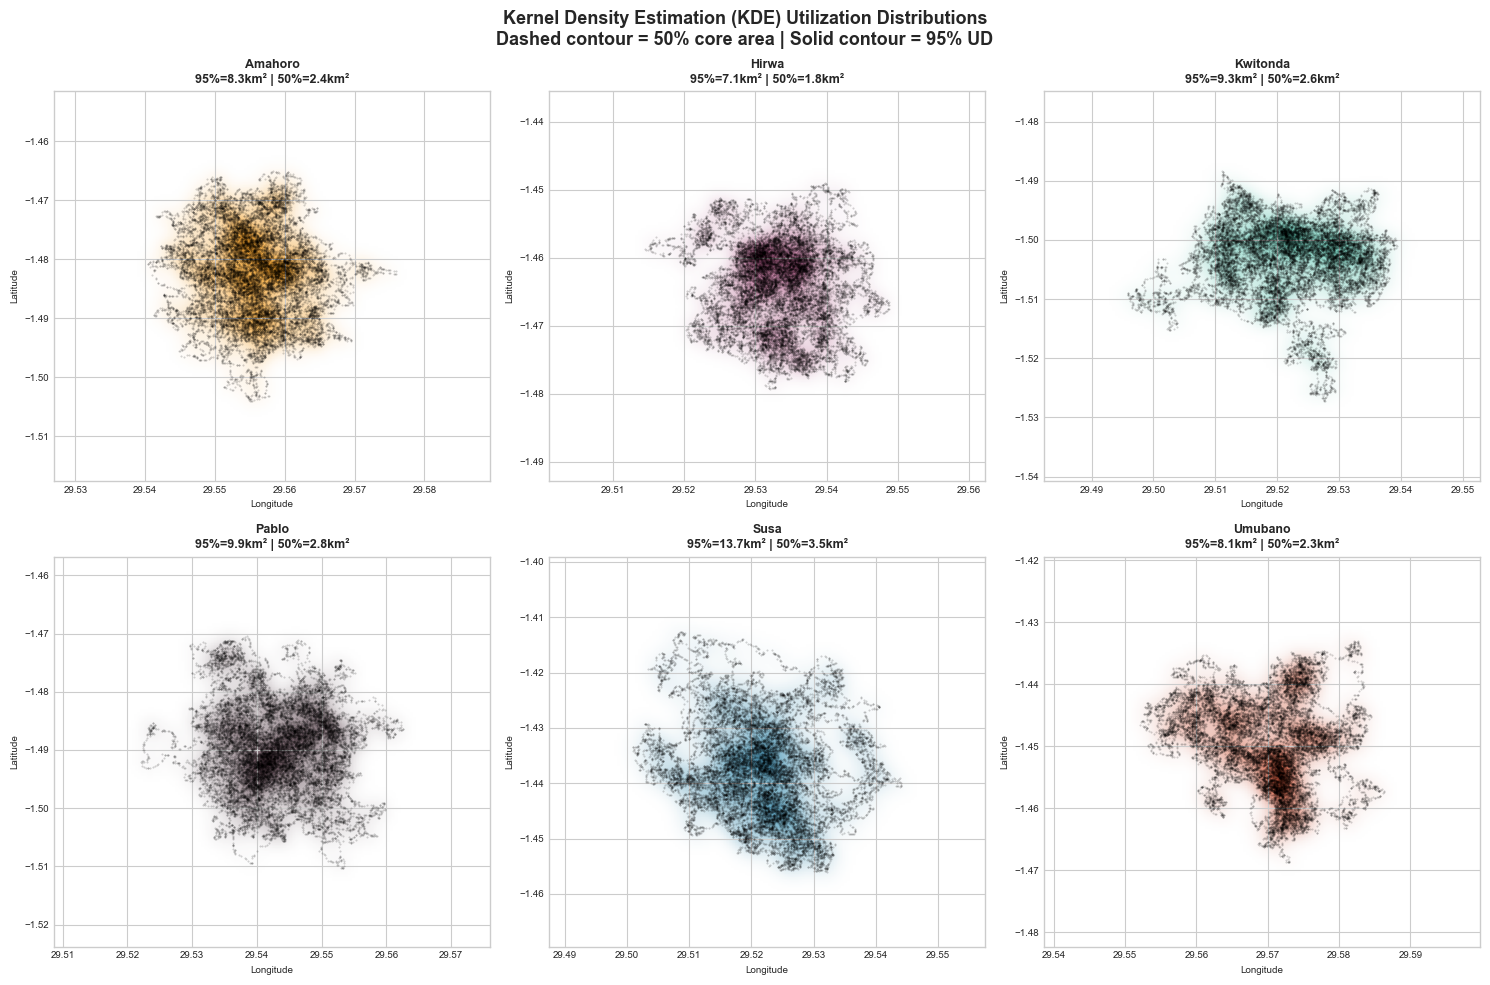

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, group in enumerate(GROUPS):
    ax = axes[i]
    res = kde_results[group]
    color = COLORS.get(group,'gray')

    # KDE density surface
    import matplotlib.colors as mcolors
    # Custom colormap from white to group color
    cmap = mcolors.LinearSegmentedColormap.from_list(
        group, ['white', color], N=256)

    im = ax.imshow(res['kde_grid'],
                   extent=[res['xi'].min(), res['xi'].max(),
                           res['yi'].min(), res['yi'].max()],
                   origin='lower', cmap=cmap, aspect='auto', alpha=0.85)

    # Contour lines for 95% and 50%
    try:
        ax.contour(res['xi'], res['yi'], res['kde_grid'],
                   levels=[res['threshold_50pct'], res['threshold_95pct']],
                   colors=['white', 'white'], linewidths=[2.5, 1.5],
                   linestyles=['--', '-'])
    except:
        pass

    # GPS points overlay
    sub = df[df['group_id']==group]
    xs, ys = sub['longitude'].values, sub['latitude'].values
    ax.scatter(xs, ys, s=0.2, alpha=0.2, color='black')

    ax.set_title(f'{group}\n95%={res["area_95pct_km2"]:.1f}km² | 50%={res["area_50pct_km2"]:.1f}km²',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=7)
    ax.set_ylabel('Latitude', fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle('Kernel Density Estimation (KDE) Utilization Distributions\n'
             'Dashed contour = 50% core area | Solid contour = 95% UD',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(project_root,'outputs','figures','03_kde_home_ranges.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Cell 6 — Home Range Comparison Table & Plot

In [21]:
# Build comparison table
hr_table = []
for group in GROUPS:
    hr_table.append({
        'Group': group,
        'Group Size': df[df['group_id']==group]['group_size'].iloc[0],
        'MCP 95% (km²)': mcp_results[group]['mcp_95']['area_km2'],
        'MCP 50% (km²)': mcp_results[group]['mcp_50']['area_km2'],
        'KDE 95% (km²)': kde_results[group]['area_95pct_km2'],
        'KDE 50% (km²)': kde_results[group]['area_50pct_km2'],
        'N Fixes': mcp_results[group]['n_fixes'],
    })
hr_df = pd.DataFrame(hr_table)
print('HOME RANGE ESTIMATES — ALL GROUPS')
print('='*65)
print(hr_df.round(2).to_string(index=False))
print('='*65)

hr_df.to_csv(os.path.join(project_root,'outputs','reports','home_range_estimates.csv'), index=False)
print('\n✅ Saved to outputs/reports/home_range_estimates.csv')

HOME RANGE ESTIMATES — ALL GROUPS
   Group  Group Size  MCP 95% (km²)  MCP 50% (km²)  KDE 95% (km²)  KDE 50% (km²)  N Fixes
 Amahoro          17           8.16           2.49           8.27           2.42    17523
   Hirwa          13           7.08           1.85           7.12           1.84    17518
Kwitonda          18           9.60           3.03           9.32           2.59    17533
   Pablo          24          10.94           2.79           9.92           2.78    17535
    Susa          28          13.32           3.73          13.71           3.54    17529
 Umubano          12           8.44           2.52           8.10           2.31    17505

✅ Saved to outputs/reports/home_range_estimates.csv


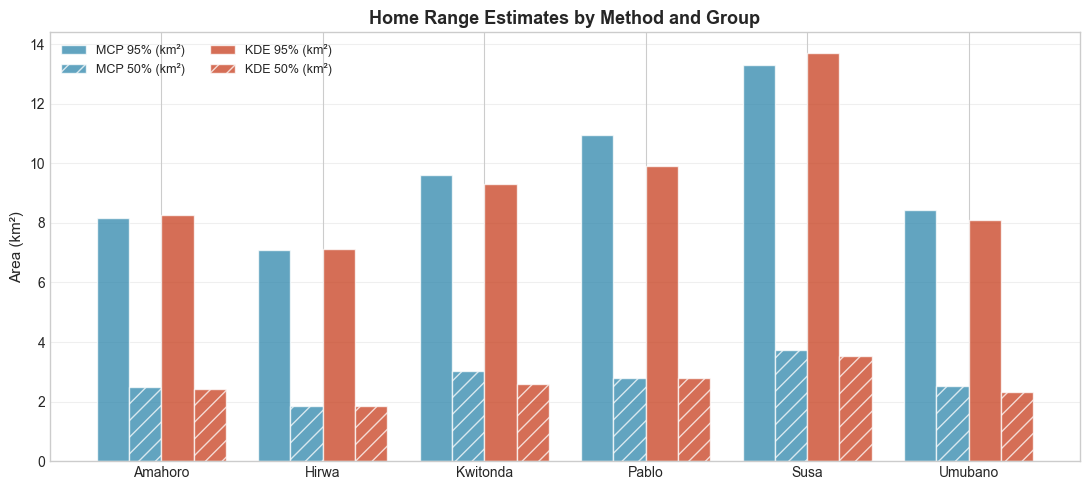

In [22]:
# Grouped bar chart
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(GROUPS))
w = 0.2
colors_hr = ['#2E86AB','#2E86AB','#C73E1D','#C73E1D']
hatches = ['','//','','//']
cols = ['MCP 95% (km²)','MCP 50% (km²)','KDE 95% (km²)','KDE 50% (km²)']
offsets = [-1.5*w, -0.5*w, 0.5*w, 1.5*w]

for col, off, hatch, clr in zip(cols, offsets, hatches, colors_hr):
    bars = ax.bar(x + off, hr_df[col], w, label=col,
                  color=clr, alpha=0.75, hatch=hatch, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(GROUPS, fontsize=10)
ax.set_ylabel('Area (km²)', fontsize=11)
ax.set_title('Home Range Estimates by Method and Group', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, ncol=2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(project_root,'outputs','figures','03_hr_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Cell 7 — Seasonal Home Range Variation

Computing seasonal home ranges...
group_id      season  mcp_95_km2  mcp_50_km2  n_fixes
 Amahoro  dry_season        6.57        2.21    10183
 Amahoro  long_rains        8.84        4.04     4419
 Amahoro short_rains        5.29        1.78     2921
   Hirwa  dry_season        6.73        2.04    10170
   Hirwa  long_rains        4.99        0.94     4422
   Hirwa short_rains        3.83        1.34     2926
Kwitonda  dry_season        7.91        2.51    10180
Kwitonda  long_rains        2.98        0.75     4425
Kwitonda short_rains        6.52        1.94     2928
   Pablo  dry_season       10.09        2.60    10176
   Pablo  long_rains        7.54        2.24     4426
   Pablo short_rains        6.95        2.86     2933
    Susa  dry_season       12.60        4.28    10203
    Susa  long_rains        9.39        3.86     4408
    Susa short_rains        4.12        1.50     2918
 Umubano  dry_season        7.68        2.72    10158
 Umubano  long_rains        4.55        1.66    

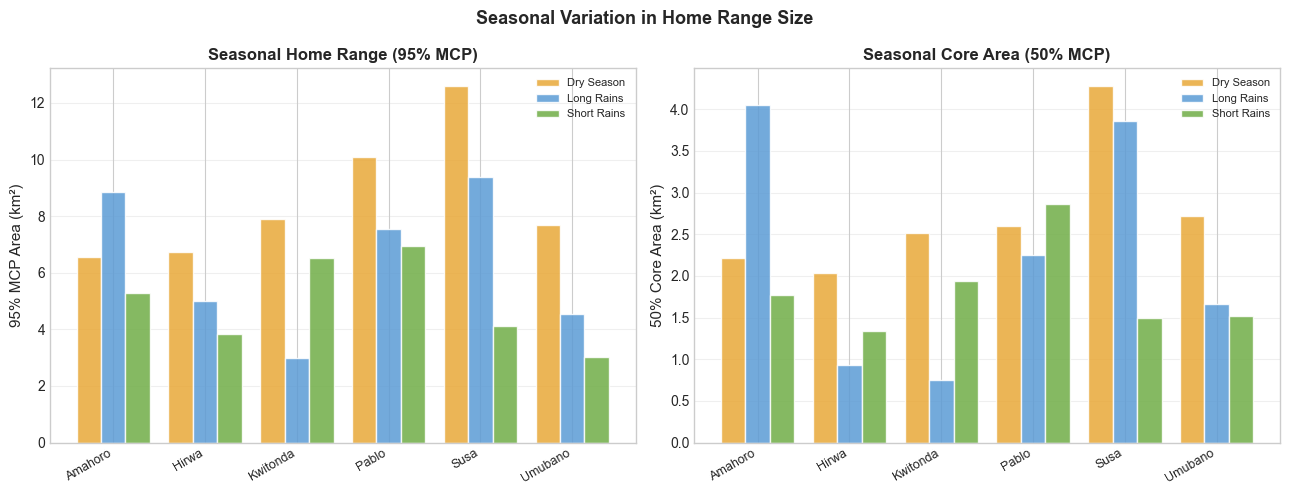

In [23]:
print('Computing seasonal home ranges...')
seasonal_df = seasonal_home_range(df)
print(seasonal_df.round(2).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
season_order = ['dry_season', 'long_rains', 'short_rains']
s_colors = {'dry_season':'#E8A838','long_rains':'#5B9BD5','short_rains':'#70AD47'}

# 95% MCP by season x group
ax = axes[0]
pivot = seasonal_df.pivot(index='group_id', columns='season', values='mcp_95_km2')
pivot = pivot.reindex(columns=[s for s in season_order if s in pivot.columns])
x = np.arange(len(pivot.index))
n_seasons = len(pivot.columns)
w = 0.8/n_seasons
for j, (season, col) in enumerate(zip(pivot.columns, [s_colors.get(s,'gray') for s in pivot.columns])):
    offset = (j - n_seasons/2 + 0.5) * w
    ax.bar(x+offset, pivot[season].values, w, label=season.replace('_',' ').title(),
           color=col, alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('95% MCP Area (km²)', fontsize=11)
ax.set_title('Seasonal Home Range (95% MCP)', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# 50% core by season x group
ax = axes[1]
pivot50 = seasonal_df.pivot(index='group_id', columns='season', values='mcp_50_km2')
pivot50 = pivot50.reindex(columns=[s for s in season_order if s in pivot50.columns])
for j, (season, col) in enumerate(zip(pivot50.columns, [s_colors.get(s,'gray') for s in pivot50.columns])):
    offset = (j - n_seasons/2 + 0.5) * w
    ax.bar(x+offset, pivot50[season].values, w, label=season.replace('_',' ').title(),
           color=col, alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(pivot50.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('50% Core Area (km²)', fontsize=11)
ax.set_title('Seasonal Core Area (50% MCP)', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Seasonal Variation in Home Range Size', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(project_root,'outputs','figures','03_seasonal_home_range.png'),
            dpi=150, bbox_inches='tight')
plt.show()